In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Load Phonemes

In [ ]:
def load_phone_vectors(csv_path):

    df = pd.read_csv(csv_path)

    phoneme_col = df.columns[0]
    feature_cols = df.columns[1:]

    # Clean feature columns
    df[feature_cols] = (
        df[feature_cols]
        .astype(str)
        .replace("−", "-", regex=True)      # unicode minus
        .replace(r"^\s*$", "0", regex=True) # empty → 0
    )

    # Convert to numeric safely
    df[feature_cols] = df[feature_cols].apply(
        lambda col: pd.to_numeric(col, errors="coerce")
    )

    # Replace NaNs with 0
    df[feature_cols] = df[feature_cols].fillna(0.0)

    phoneme_to_vec = {}

    for _, row in df.iterrows():
        phoneme = row[phoneme_col]

        # IMPORTANT: force float32 numpy array
        vec = torch.tensor(
            row[feature_cols].astype(np.float32).values,
            dtype=torch.float32
        )

        phoneme_to_vec[phoneme] = vec

    return phoneme_to_vec, len(feature_cols)

In [ ]:
DEVANAGARI_MATRAS = {
    "ा": "आ", "ि": "इ", "ी": "ई", "ु": "उ", "ू": "ऊ",
    "ृ": "ऋ", "ॄ": "ॠ", "ॢ": "ऌ", "ॣ": "ॡ",
    "े": "ए", "ै": "ऐ", "ो": "ओ", "ौ": "औ",
}

# independent vowels set
DEVANAGARI_VOWELS = set(list("अआइईउऊऋॠऌॡएऐओऔ"))

# consonants range roughly (क..ह) — we'll treat these as consonants
# include nukta & other combining marks handled separately
DEVANAGARI_CONSONANTS = set(list(
    "कखगघङचछजझञटठडढणतथदधनपफबभमयऱलवशषसह"
))
# add retroflex/rule variants if needed (adjust per data)
# Halant, nukta, anusvara, visarga
HALANT = "\u094D"     # ्
NUKTA = "\u093C"      # ़
ANUSVARA = "ं"
VISARGA = "ः"
CANDRABINDU = "ँ"

PHONETIC_MODIFIERS = {ANUSVARA, VISARGA, CANDRABINDU}

def akshara_to_phonemes(token):

    token = unicodedata.normalize("NFC", token.strip())
    phonemes = []
    i = 0
    chars = list(token)

    while i < len(chars):
        ch = chars[i]

        # independent vowel
        if ch in DEVANAGARI_VOWELS:
            phonemes.append(ch)
            i += 1
            continue

        # modifier symbols that act like separate phonemes (anusvara/visarga)
        if ch in PHONETIC_MODIFIERS:
            phonemes.append(ch)
            i += 1
            continue

        # consonant (including possible nukta immediately after)
        if ch in DEVANAGARI_CONSONANTS:
            base = ch
            i += 1
            # nukta (rare) e.g. क़
            if i < len(chars) and chars[i] == NUKTA:
                base = base + chars[i]
                i += 1

            # halant means explicit consonant without inherent vowel
            if i < len(chars) and chars[i] == HALANT:
                # append base (consonant) only, skip halant
                phonemes.append(base)
                i += 1
                continue

            # vowel matra attached? map to independent vowel and append base+vowel
            if i < len(chars) and chars[i] in DEVANAGARI_MATRAS:
                mat = chars[i]
                vowel = DEVANAGARI_MATRAS[mat]
                phonemes.append(base)
                phonemes.append(vowel)
                i += 1
                continue

            # If no matra/halant follows, append consonant (in many phonemic analyses
            # the inherent vowel 'अ' is present. Depending on your phoneme vectors you
            # may want to append 'अ' as well. Here we append the consonant alone,
            # which matches a common phoneme mapping where consonant segments are separate.)
            phonemes.append(base)
            continue

        # standalone matra (shouldn't usually happen), convert to vowel
        if ch in DEVANAGARI_MATRAS:
            phonemes.append(DEVANAGARI_MATRAS[ch])
            i += 1
            continue

        # otherwise: unknown char, append as-is (fallback)
        phonemes.append(ch)
        i += 1

    return phonemes


Load Triplets

In [ ]:
def load_triplets(csv_path):
    df = pd.read_excel(csv_path)

    triplets = []
    for _, row in df.iterrows():
        triplets.append({
            "anchor": row["anchor"].split(),
            "positive": row["positive"].split(),
            "negative": row["negative"].split()
        })
    return triplets

Contrastive learning Dataset

In [ ]:
class ContrastivePhoneticDataset(Dataset):
    def __init__(self, triplets, phoneme_to_vec, dim):
        self.triplets = triplets
        self.phoneme_to_vec = phoneme_to_vec
        self.dim = dim
        self.zero = torch.zeros(dim, dtype=torch.float32)

    def encode(self, word):

    # If word is list (because of .split()), convert back to string
      if isinstance(word, list):
        word = "".join(word)

      phoneme_seq = akshara_to_phonemes(word)

      vectors = []
      for p in phoneme_seq:
        if p in self.phoneme_to_vec:
            vectors.append(self.phoneme_to_vec[p])
        else:
            vectors.append(self.zero)

      return torch.stack(vectors)

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        triplet = self.triplets[idx]

        anchor_tensor = self.encode(triplet["anchor"])
        positive_tensor = self.encode(triplet["positive"])

        return anchor_tensor, positive_tensor

Collate

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    anchors, positives = zip(*batch)

    anchors = pad_sequence(anchors, batch_first=True)
    positives = pad_sequence(positives, batch_first=True)

    return anchors.to(device), positives.to(device)

Model Aechitecture

In [ ]:
class BiLSTMAttentionEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, proj_dim=128):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Linear(hidden_dim * 2, 1)

        self.projection = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, proj_dim)
        )

    def forward(self, x):

        h, _ = self.lstm(x)  # [B, T, 2H]

        attn_scores = self.attn(h)
        attn_weights = torch.softmax(attn_scores, dim=1)

        pooled = torch.sum(attn_weights * h, dim=1)

        z = self.projection(pooled)
        z = F.normalize(z, p=2, dim=1)

        return z

Info NCE loss

In [ ]:
# def info_nce_euclidean(z_anchor, z_positive, temperature=0.1):

#     # Pairwise squared Euclidean distances
#     dist = torch.cdist(z_anchor, z_positive, p=2) ** 2

#     # Convert to similarity
#     sim = -dist / temperature

#     labels = torch.arange(sim.size(0)).to(sim.device)

#     w =

#     loss = F.cross_entropy(sim, labels)

#     return loss

In [ ]:
def weighted_info_nce_euclidean(
    z_anchor,
    z_positive,
    articulatory_dist_matrix,
    temperature=0.1,
    gamma=1.0
):


    # Pairwise squared Euclidean distance
    dist = torch.cdist(z_anchor, z_positive, p=2) ** 2  # [B, B]

    # Convert to similarity
    sim = -dist / temperature  # [B, B]

    # Compute weights w_ij = exp(-gamma * A(i,j))
    weights = torch.exp(-gamma * articulatory_dist_matrix)  # [B, B]

    # Apply weights inside denominator (log-softmax trick)
    weighted_exp_sim = weights * torch.exp(sim)  # [B, B]

    # Numerator = diagonal elements
    numerator = torch.diag(torch.exp(sim))  # [B]

    # Denominator = row-wise sum
    denominator = weighted_exp_sim.sum(dim=1)  # [B]

    # Final loss
    loss = -torch.log(numerator / denominator)

    return loss.mean()

Train / Validation Split

In [ ]:
phoneme_to_vec, dim = load_phone_vectors("/content/drive/MyDrive/Sanskrit NLP/sanskrit_phoneme_vectors (1).csv")
triplets = load_triplets("/content/drive/MyDrive/Sanskrit NLP/sridath_system_panphon_triplets_3.xlsx")

train_triplets, val_triplets = train_test_split(
    triplets, test_size=0.2, random_state=42
)

train_dataset = ContrastivePhoneticDataset(train_triplets, phoneme_to_vec, dim)
val_dataset = ContrastivePhoneticDataset(val_triplets, phoneme_to_vec, dim)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

Training Loop

In [ ]:
import copy

# Initialize model and optimizer - these lines were missing
model = BiLSTMAttentionEncoder(dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 200              # allow large upper bound
PATIENCE = 10             # stop if no improvement for 10 epochs
best_val_loss = float("inf")
patience_counter = 0

best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # =========================
    # TRAIN
    # =========================
    model.train()
    train_loss = 0

    for anchors, positives in train_loader:

        z_a = model(anchors)
        z_p = model(positives)

        loss = info_nce_euclidean(z_a, z_p)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for anchors, positives in val_loader:

            z_a = model(anchors)
            z_p = model(positives)

            loss = info_nce_euclidean(z_a, z_p)
            val_loss += loss.item()

            sim = -torch.cdist(z_a, z_p) ** 2
            preds = sim.argmax(dim=1)
            labels = torch.arange(sim.size(0)).to(device)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | Val Acc: {val_acc:.4f}")


    # =========================
    # EARLY STOPPING CHECK
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, "contrastive_InfoNCE_model.pkl")
        patience_counter = 0

        print("New best model saved.")

    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(" Early stopping triggered.")
            break


# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(best_model_state)
print("Best model loaded (lowest validation loss).")

Epoch 1
Train Loss: 0.711253 | Val Loss: 0.369657 | Val Acc: 0.8904
New best model saved.
Epoch 2
Train Loss: 0.292995 | Val Loss: 0.273854 | Val Acc: 0.9152
New best model saved.
Epoch 3
Train Loss: 0.232238 | Val Loss: 0.240798 | Val Acc: 0.9248
New best model saved.
Epoch 4
Train Loss: 0.197291 | Val Loss: 0.208539 | Val Acc: 0.9340
New best model saved.
Epoch 5
Train Loss: 0.177928 | Val Loss: 0.194417 | Val Acc: 0.9361
New best model saved.
Epoch 6
Train Loss: 0.165691 | Val Loss: 0.181079 | Val Acc: 0.9404
New best model saved.
Epoch 7
Train Loss: 0.147706 | Val Loss: 0.177915 | Val Acc: 0.9422
New best model saved.
Epoch 8
Train Loss: 0.142334 | Val Loss: 0.162909 | Val Acc: 0.9479
New best model saved.
Epoch 9
Train Loss: 0.138750 | Val Loss: 0.171944 | Val Acc: 0.9450
No improvement. Patience: 1/10
Epoch 10
Train Loss: 0.127049 | Val Loss: 0.164258 | Val Acc: 0.9472
No improvement. Patience: 2/10
Epoch 11
Train Loss: 0.117055 | Val Loss: 0.160616 | Val Acc: 0.9450
New best mod

visualization

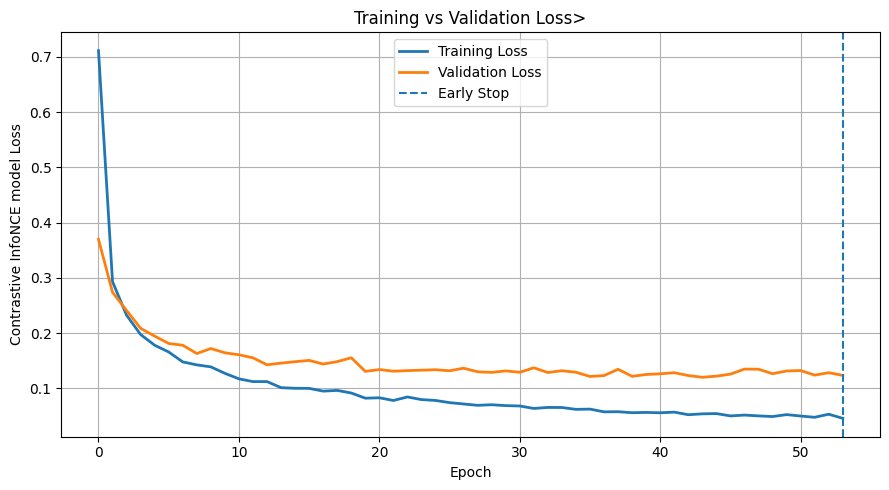

In [ ]:
import matplotlib.pyplot as plt

stop_epoch = len(train_losses)

plt.figure(figsize=(9, 5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.axvline(x=stop_epoch-1, linestyle="--", label="Early Stop")

plt.xlabel("Epoch")
plt.ylabel("Contrastive InfoNCE model Loss")
plt.title("Training vs Validation Loss>")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Load the model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = BiLSTMAttentionEncoder(input_dim=dim)
model.load_state_dict(torch.load("/content/contrastive_InfoNCE_model.pkl", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
def get_embedding(word):

    phoneme_seq = akshara_to_phonemes(word)

    vectors = []
    for p in phoneme_seq:
        if p in phoneme_to_vec:
            vectors.append(phoneme_to_vec[p])
        else:
            vectors.append(torch.zeros(dim))

    tensor = torch.stack(vectors).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(tensor)

    return embedding.squeeze(0)

In [ ]:
word_pairs = [
    ("माबि", "माभीभ"),
    ("इहैधि", "यहेधी"),
    ("इषुरि", "इशूरी"),
    ("उदेणी", "उधेनि"),
    ("इयमन्", "यमन्त"),
    ("नवप्", "प्राण"),
    ("कुल", "कूल"),
    ("सित", "सीता"),
    ("दिन", "दीन"),
    ("आसन", "आसन्न"),
    ("प्रवाह", "पर्वाह"),
    ("कर्म", "क्रम"),
    ("ग्रह", "गृह"),
    ("येवकं", "ऐवकं"),
    ("विश्पतिं", "विस्पंति")
]

In [ ]:
def euclidean_distance(e1, e2):
    return torch.norm(e1 - e2, p=2).item()
def cosine_distance(e1, e2):

    e1_norm = torch.norm(e1)
    e2_norm = torch.norm(e2)
    if e1_norm == 0 or e2_norm == 0:
        return 1.0
    cosine_sim = torch.dot(e1, e2) / (e1_norm * e2_norm)
    return (1 - cosine_sim).item()

for w1, w2 in word_pairs:
    try:
        emb1 = get_embedding(w1)
        emb2 = get_embedding(w2)

        euclidean_dist = euclidean_distance(emb1, emb2)
        cos_dist = cosine_distance(emb1, emb2)

        print(f"{w1} - {w2} | Euclidean distance: {euclidean_dist:.4f} | Cosine distance: {cos_dist:.4f}")

    except Exception as e:
        print(f"Error processing ({w1}, {w2}): {e}")

माबि - माभीभ | Euclidean distance: 0.7727 | Cosine distance: 0.2985
इहैधि - यहेधी | Euclidean distance: 1.0283 | Cosine distance: 0.5287
इषुरि - इशूरी | Euclidean distance: 0.4004 | Cosine distance: 0.0802
उदेणी - उधेनि | Euclidean distance: 0.5113 | Cosine distance: 0.1307
इयमन् - यमन्त | Euclidean distance: 1.0861 | Cosine distance: 0.5898
नवप् - प्राण | Euclidean distance: 1.5365 | Cosine distance: 1.1805
कुल - कूल | Euclidean distance: 0.1559 | Cosine distance: 0.0122
सित - सीता | Euclidean distance: 0.2985 | Cosine distance: 0.0446
दिन - दीन | Euclidean distance: 0.1156 | Cosine distance: 0.0067
आसन - आसन्न | Euclidean distance: 0.5769 | Cosine distance: 0.1664
प्रवाह - पर्वाह | Euclidean distance: 0.3367 | Cosine distance: 0.0567
कर्म - क्रम | Euclidean distance: 0.3130 | Cosine distance: 0.0490
ग्रह - गृह | Euclidean distance: 0.6857 | Cosine distance: 0.2351
येवकं - ऐवकं | Euclidean distance: 0.8289 | Cosine distance: 0.3435
विश्पतिं - विस्पंति | Euclidean distance: 0.5398 | Co

* माबि - माभीभ | Euclidean distance: 0.7740 | Cosine distance: 0.2995
* इहैधि - यहेधी | Euclidean distance: 1.1007 | Cosine distance: 0.6058
* इषुरि - इशूरी | Euclidean distance: 0.4294 | Cosine distance: 0.0922
* उदेणी - उधेनि | Euclidean distance: 0.4974 | Cosine distance: 0.1237
* इयमन् - यमन्त | Euclidean distance: 1.2675 | Cosine distance: 0.8033
* नवप् - प्राण | Euclidean distance: 1.4823 | Cosine distance: 1.0987
* कुल - कूल | Euclidean distance: 0.1119 | Cosine distance: 0.0063
* सित - सीता | Euclidean distance: 0.2592 | Cosine distance: 0.0336
* दिन - दीन | Euclidean distance: 0.1097 | Cosine distance: 0.0060
* आसन - आसन्न | Euclidean distance: 0.5037 | Cosine distance: 0.1269
* प्रवाह - पर्वाह | Euclidean distance: 0.2999 | Cosine distance: 0.0450
* कर्म - क्रम | Euclidean distance: 0.3272 | Cosine distance: 0.0535
* ग्रह - गृह | Euclidean distance: 0.5229 | Cosine distance: 0.1367
* येवकं - ऐवकं | Euclidean distance: 1.0527 | Cosine distance: 0.5541
* विश्पतिं - विस्पंति | Euclidean distance: 0.4107 | Cosine distance: 0.0843
